In [2]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import requests
import datetime
import base64
from pathlib import Path
from dotenv import load_dotenv
from cryptography.hazmat.primitives import serialization, hashes
from cryptography.hazmat.primitives.asymmetric import padding
from cryptography.hazmat.backends import default_backend

/Users/olegglotov/Documents/CHICAGO code/Winter/FINM - ML for Finance/ML-for-finance-project/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


In [3]:
PROJECT_DIR = Path().resolve()

load_dotenv(PROJECT_DIR / ".env")
API_KEY_ID       = os.environ["API_KEY_ID"]
PRIVATE_KEY_PATH = PROJECT_DIR / "private_key.pem"

BASE_URL = "https://api.elections.kalshi.com/trade-api/v2"


# --- Auth helpers ---
def _load_key(path):
    with open(path, "rb") as f:
        return serialization.load_pem_private_key(f.read(), password=None, backend=default_backend())

def _sign(private_key, timestamp_ms: str, method: str, path: str) -> str:
    path_no_query = path.split("?")[0]
    msg = f"{timestamp_ms}{method}{path_no_query}".encode()
    sig = private_key.sign(
        msg,
        padding.PSS(mgf=padding.MGF1(hashes.SHA256()), salt_length=padding.PSS.DIGEST_LENGTH),
        hashes.SHA256(),
    )
    return base64.b64encode(sig).decode()

def kalshi_get(path: str, params: dict = None, _retries: int = 5) -> dict:
    for attempt in range(_retries):
        ts = str(int(datetime.datetime.now().timestamp() * 1000))
        key = _load_key(PRIVATE_KEY_PATH)
        sig = _sign(key, ts, "GET", path)
        headers = {
            "KALSHI-ACCESS-KEY":       API_KEY_ID,
            "KALSHI-ACCESS-TIMESTAMP": ts,
            "KALSHI-ACCESS-SIGNATURE": sig,
        }
        resp = requests.get(BASE_URL + path, params=params, headers=headers)
        if resp.status_code == 429:
            wait = 2 ** attempt
            print(f"    429 — waiting {wait}s...")
            time.sleep(wait)
            continue
        resp.raise_for_status()
        return resp.json()
    raise RuntimeError(f"Max retries exceeded for {path}")

print(f"API key loaded: {API_KEY_ID[:8]}...")
print(f"Private key:    {PRIVATE_KEY_PATH}")

API key loaded: 83fb167e...
Private key:    /Users/olegglotov/Documents/CHICAGO code/Winter/FINM - ML for Finance/ML-for-finance-project/private_key.pem


In [6]:
# --- Step 1: Fetch ALL settled KXNBAGAME markets (paginated) ---
import time

SERIES = "KXNBAGAME"
SEASON_START = int(datetime.datetime(2025, 10, 10, tzinfo=datetime.timezone.utc).timestamp())

all_markets = []
cursor = None

while True:
    params = {"series_ticker": SERIES, "status": "settled",
              "min_close_ts": SEASON_START, "limit": 1000}
    if cursor:
        params["cursor"] = cursor
    resp = kalshi_get("/markets", params=params)
    page = resp["markets"]
    all_markets.extend(page)
    cursor = resp.get("cursor")
    print(f"  fetched {len(page)} markets  (total so far: {len(all_markets)})")
    if not cursor:
        break

# Deduplicate: one market per event (alphabetically first ticker = away-team side)
seen_events = {}
for m in all_markets:
    ev = m["event_ticker"]
    if ev not in seen_events or m["ticker"] < seen_events[ev]["ticker"]:
        seen_events[ev] = m

games_meta = sorted(seen_events.values(), key=lambda m: m["close_time"])
print(f"\n{len(games_meta)} unique games from {games_meta[0]['close_time'][:10]} "
      f"to {games_meta[-1]['close_time'][:10]}")

  fetched 1000 markets  (total so far: 1000)
  fetched 944 markets  (total so far: 1944)

972 unique games from 2025-10-10 to 2026-03-05


In [11]:
# --- Step 2: Pull hourly candlesticks for every game ---
def iso_to_ts(s):
    # pd.Timestamp handles all ISO 8601 variants incl. variable sub-second precision
    return int(pd.Timestamp(s).timestamp())

def parse_slug(ticker):
    teams_part = ticker.split("-")[1][7:]
    return f"{teams_part[:3]} - {teams_part[3:]}"

def get_hourly_df(market_meta):
    ticker   = market_meta["ticker"]
    start_ts = iso_to_ts(market_meta["open_time"])
    end_ts   = iso_to_ts(market_meta["close_time"])

    raw = kalshi_get(
        f"/series/{SERIES}/markets/{ticker}/candlesticks",
        params={"start_ts": start_ts, "end_ts": end_ts,
                "period_interval": 60, "include_latest_before_start": "true"},
    )
    candles = raw.get("candlesticks", [])

    rows = []
    for c in candles:
        p = c["price"]
        last_price = p["close"] if p["close"] is not None else p["previous"]
        if last_price is None:
            continue
        rows.append({
            "time":    pd.Timestamp(c["end_period_ts"], unit="s", tz="UTC"),
            "open":    (p["open"]  if p["open"]  is not None else last_price) / 100,
            "high":    (p["high"]  if p["high"]  is not None else last_price) / 100,
            "low":     (p["low"]   if p["low"]   is not None else last_price) / 100,
            "close":   last_price / 100,
            "yes_bid": c["yes_bid"]["close"] / 100,
            "yes_ask": c["yes_ask"]["close"] / 100,
            "volume":  c["volume"],
        })

    df = pd.DataFrame(rows).set_index("time")
    if not df.empty:
        df["mid"] = (df["yes_bid"] + df["yes_ask"]) / 2
    return df

games = []
errors = []

for i, m in enumerate(games_meta):
    try:
        df = get_hourly_df(m)
        if df.empty or len(df) < 4:
            errors.append((m["ticker"], "too few candles"))
            continue
        games.append({
            "ticker":        m["ticker"],
            "slug":          parse_slug(m["ticker"]),
            "close_time":    m["close_time"],
            "df":            df,
            "pre_close_mid": df["mid"].iloc[-4],
        })
    except Exception as e:
        errors.append((m["ticker"], str(e)))

    if (i + 1) % 50 == 0:
        print(f"  {i+1}/{len(games_meta)} done  ({len(errors)} errors so far)")

print(f"\nDone: {len(games)} games, {len(errors)} errors")
if errors:
    print("Errors:", errors[:5])

    429 — waiting 1s...
    429 — waiting 1s...
    429 — waiting 1s...
  50/966 done  (0 errors so far)
    429 — waiting 1s...
    429 — waiting 1s...
    429 — waiting 1s...
    429 — waiting 1s...
    429 — waiting 1s...
  100/966 done  (0 errors so far)
    429 — waiting 1s...
    429 — waiting 1s...
    429 — waiting 1s...
  150/966 done  (0 errors so far)
    429 — waiting 1s...
    429 — waiting 1s...
  200/966 done  (0 errors so far)
    429 — waiting 1s...
    429 — waiting 1s...
    429 — waiting 1s...
  250/966 done  (0 errors so far)
  300/966 done  (0 errors so far)
    429 — waiting 1s...
    429 — waiting 1s...
  350/966 done  (0 errors so far)
    429 — waiting 1s...
    429 — waiting 1s...
    429 — waiting 1s...
    429 — waiting 1s...
    429 — waiting 1s...
  400/966 done  (0 errors so far)
    429 — waiting 1s...
    429 — waiting 1s...
    429 — waiting 1s...
    429 — waiting 1s...
  450/966 done  (0 errors so far)
    429 — waiting 1s...
    429 — waiting 1s...

In [7]:
# --- Save parsed data ---
DATA_DIR = PROJECT_DIR / "data"
DATA_DIR.mkdir(exist_ok=True)

# 1. Summary table (one row per game)
summary_save = pd.DataFrame([{
    "slug":           g["slug"],
    "ticker":         g["ticker"],
    "close_time":     g["close_time"],
    "pre_close_mid":  g["pre_close_mid"],
} for g in games])
summary_save.to_parquet(DATA_DIR / "summary.parquet", index=False)

# 2. All hourly candles combined (one row per candle)
candles_all = pd.concat(
    [g["df"].assign(slug=g["slug"], ticker=g["ticker"]) for g in games]
).reset_index()   # brings 'time' back as a column
candles_all.to_parquet(DATA_DIR / "candles.parquet", index=False)

print(f"Saved {len(summary_save)} games and {len(candles_all)} candle rows to {DATA_DIR}/")

NameError: name 'games' is not defined

In [6]:
PROJECT_DIR = Path().resolve()
DATA_DIR = PROJECT_DIR / "data"

summary = pd.read_parquet(DATA_DIR / "summary.parquet")
candles = pd.read_parquet(DATA_DIR / "candles.parquet")

In [7]:
# --- Step 3: Summary DataFrame (loaded from parquet) ---
summary["close_time"] = pd.to_datetime(summary["close_time"], format="ISO8601", utc=True)
summary = summary.sort_values("close_time").reset_index(drop=True)
print(f"{len(summary)} games")
summary

966 games


,slug,ticker,close_time,pre_close_mid
0,PHX - BKN,KXNBAGAME-25OCT10PHXBKN-BKN,2025-10-10 19:04:36.712661+00:00,0.005
1,BOS - TOR,KXNBAGAME-25OCT10BOSTOR-BOS,2025-10-10 23:49:38.818097+00:00,0.495
2,ORL - PHI,KXNBAGAME-25OCT10ORLPHI-ORL,2025-10-10 23:49:38.868154+00:00,0.650
3,UTA - SAS,KXNBAGAME-25OCT10UTASAS-SAS,2025-10-11 02:55:20.161794+00:00,0.695
4,SAC - POR,KXNBAGAME-25OCT10SACPOR-POR,2025-10-11 04:56:11.126916+00:00,0.575
...,...,...,...,...
961,OKC - CHI,KXNBAGAME-26MAR03OKCCHI-CHI,2026-03-04 03:33:59+00:00,0.225
962,MEM - MIN,KXNBAGAME-26MAR03MEMMIN-MEM,2026-03-04 03:40:51+00:00,0.145
963,SAS - PHI,KXNBAGAME-26MAR03SASPHI-PHI,2026-03-04 04:01:10+00:00,0.265
964,NOP - LAL,KXNBAGAME-26MAR03NOPLAL-LAL,2026-03-04 06:15:53+00:00,0.745


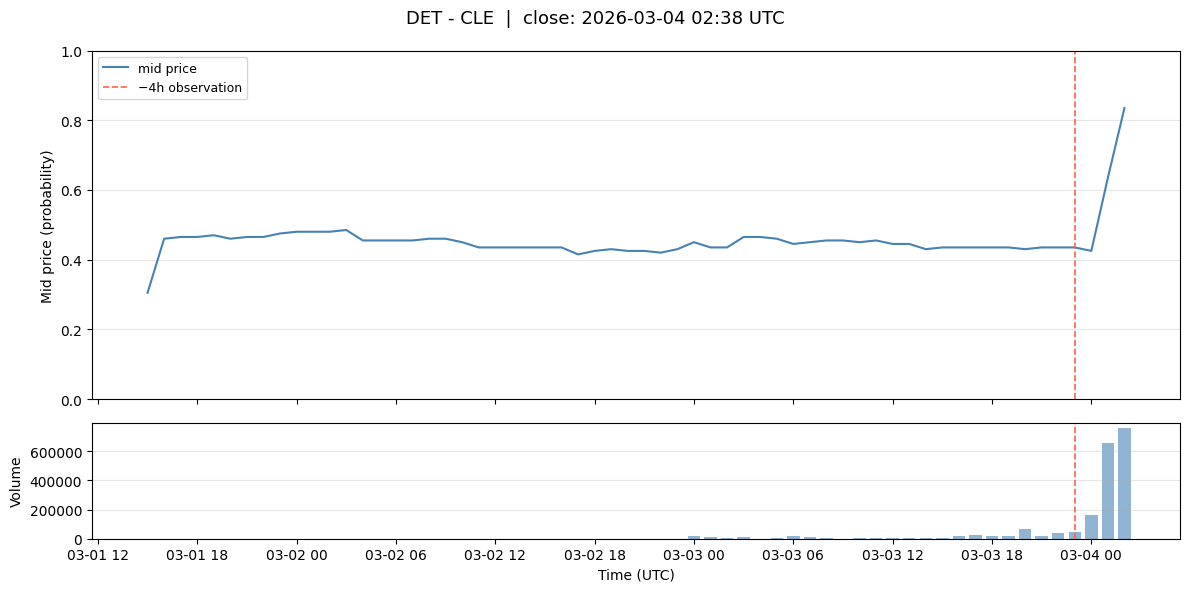

Pre-close mid (−4h): 0.435


In [20]:
# --- Sample game: midprice dynamics + volume ---
sample = summary.iloc[-10]  # pick a game from the middle of the season
game_candles = candles[candles["ticker"] == sample["ticker"]].copy()
game_candles = game_candles.sort_values("time").reset_index(drop=True)

# The observation point is the 4th-from-last candle
obs_time = game_candles["time"].iloc[-4]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 6), sharex=True,
                                gridspec_kw={"height_ratios": [3, 1]})
fig.suptitle(f"{sample['slug']}  |  close: {sample['close_time'].strftime('%Y-%m-%d %H:%M UTC')}",
             fontsize=13)

# -- Midprice --
ax1.plot(game_candles["time"], game_candles["mid"], color="steelblue", linewidth=1.5, label="mid price")
ax1.axvline(obs_time, color="tomato", linestyle="--", linewidth=1.2, label="−4h observation")
ax1.set_ylabel("Mid price (probability)")
ax1.set_ylim(0, 1)
ax1.legend(fontsize=9)
ax1.grid(axis="y", alpha=0.3)

# -- Volume --
ax2.bar(game_candles["time"], game_candles["volume"],
        width=pd.Timedelta(minutes=45), color="steelblue", alpha=0.6)
ax2.axvline(obs_time, color="tomato", linestyle="--", linewidth=1.2)
ax2.set_ylabel("Volume")
ax2.set_xlabel("Time (UTC)")
ax2.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Pre-close mid (−4h): {sample['pre_close_mid']:.3f}")

In [14]:
summary.to_csv("nba_games_summary.csv", index=False)